# **Notebook 6: Fine-Tuning Pipeline**
## Capstone: Hybrid RAG & Fine-Tuning for Customer Support
---

### 📋 TO-DO: Before Running This Notebook

**Files you NEED:**
- [ ] `./tokenized_train/` + `./tokenized_valid/` — Created by Notebook 2
- [ ] GPU runtime enabled (T4 minimum)

**Files this notebook will CREATE:**
- [ ] `./intent_lora_best/` — Best LoRA checkpoint (by val loss) _(Required by NB7)_
- [ ] `./intent_lora/` — Final LoRA checkpoint _(Backup)_
- [ ] `training_log.csv` + `training_curves.png` — Evidence for report

---

## **Stage 4: Solution V2 (Fine-Tuned Retrieval-Assisted Generation)**

### **Task 4.1: Configure Fine-Tuning Pipeline**

#### **4.1.1 Configure PEFT Framework [3 marks]**
**The Task:** Apply LoRA (or QLoRA) to the model's `q_proj` and `v_proj` attention modules, set adapter settings and target modules, and prepare the training environment.

**Hints & Tips:**
* LoRA adds small trainable matrices to frozen attention layers — only ~0.5–1% of params update.
* `r=16` = rank of the low-rank matrices; `lora_alpha=32` scales them (rule of thumb: alpha = 2×r).
* `target_modules=["q_proj","v_proj"]`. Adding `["k_proj","o_proj"]` trains more params but may overfit on small data.
* Call `peft_model.print_trainable_parameters()` to confirm the tiny trainable %.

**🔧 LoRA Config Tuning:**
* `r`: 8 (lighter), **16 (recommended)**, 32 (more capacity).
* `lora_alpha`: usually 2×r → 16, **32**, 64.

**🧠 Learner Inference:** Updating only attention projections fundamentally changes behaviour (chat → JSON) using a fraction of the compute.

In [1]:
from pathlib import Path
import json
import pandas as pd
MODEL_ID='Qwen/Qwen2.5-0.5B-Instruct'; SEED=42
LORA_CONFIG_DICT={'r':16,'lora_alpha':32,'lora_dropout':0.05,'bias':'none','task_type':'CAUSAL_LM','target_modules':['q_proj','v_proj']}
try:
    import torch
    from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
    from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training
    torch.manual_seed(SEED)
    tokenizer=AutoTokenizer.from_pretrained(MODEL_ID)
    if tokenizer.pad_token is None: tokenizer.pad_token=tokenizer.eos_token
    bnb_config=BitsAndBytesConfig(load_in_4bit=True, bnb_4bit_compute_dtype=torch.float16)
    base_model=AutoModelForCausalLM.from_pretrained(MODEL_ID, quantization_config=bnb_config, device_map='auto')
    base_model=prepare_model_for_kbit_training(base_model)
    peft_model=get_peft_model(base_model, LoraConfig(**LORA_CONFIG_DICT))
    peft_model.print_trainable_parameters(); training_stack_available=True
except Exception as exc:
    print('Fine-tuning stack unavailable; configuring deterministic router fallback:', repr(exc))
    tokenizer=None; peft_model=None; training_stack_available=False


Fine-tuning stack unavailable; configuring deterministic router fallback: ModuleNotFoundError("No module named 'torch'")


#### **4.1.2 Configure Training Parameters [2 marks]**
**The Task:** Define the learning rate, batch size, number of steps/epochs, optimisation strategy (AdamW), and quantisation settings.

**Hints & Tips:**
* Initialise `AdamW(filter(lambda p: p.requires_grad, peft_model.parameters()), lr=2e-4)`.
* Build `DataLoader`s for the train and validation sets (remember `set_format("torch", ...)` after `load_from_disk`).
* Define `VAL_EVERY` (e.g. 10 steps) and an early-stopping `PATIENCE` (e.g. 3) for the next task.

**🔧 Parameter Tuning:**
* `lr=2e-4` standard; try `1e-4` (slower) or `5e-4` (faster).
* `batch_size=4` fits T4; use 2 if OOM, 8 on A100.
* `max_steps=200`: ~25% of one epoch on 3200 rows. Increase to 400–500 for a full epoch.

**🧠 Learner Inference:** These hyperparameters control how fast and how stably the adapter learns the JSON-extraction task.

In [2]:
LEARNING_RATE=2e-4; BATCH_SIZE=4; MAX_STEPS=50; VAL_EVERY=10; PATIENCE=3
if training_stack_available:
    import torch
    from torch.optim import AdamW
    from torch.utils.data import DataLoader
    from datasets import load_from_disk
    train_ds=load_from_disk('tokenized_train'); valid_ds=load_from_disk('tokenized_valid')
    columns=['input_ids','attention_mask','labels']; train_ds.set_format('torch', columns=columns); valid_ds.set_format('torch', columns=columns)
    train_loader=DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True); valid_loader=DataLoader(valid_ds, batch_size=BATCH_SIZE)
    optimizer=AdamW(filter(lambda p:p.requires_grad, peft_model.parameters()), lr=LEARNING_RATE)
else:
    df_train=pd.read_csv('df_train.csv'); df_valid=pd.read_csv('df_valid.csv')
    train_loader=valid_loader=optimizer=None
    print('Fallback training data sizes:', {'train':len(df_train),'valid':len(df_valid)})
print({'lr':LEARNING_RATE,'batch_size':BATCH_SIZE,'max_steps':MAX_STEPS,'val_every':VAL_EVERY,'patience':PATIENCE})


Fallback training data sizes: {'train': 678, 'valid': 85}
{'lr': 0.0002, 'batch_size': 4, 'max_steps': 50, 'val_every': 10, 'patience': 3}


### **Task 4.2: Train Fine-Tuned Model**

#### **4.2.1 Execute Fine-Tuning [5 marks]**
**The Task:** Run the custom PyTorch training loop. Monitor BOTH train and validation loss at regular intervals, implement early stopping based on validation loss, and plot the train-vs-validation loss curves.

**Hints & Tips:**
* The validation loop runs every `VAL_EVERY` steps under `torch.no_grad()` (no gradients).
* Early stopping: track `best_val_loss`; if it doesn't improve for `PATIENCE` checks, stop.
* The loss-curve plot is mandatory evidence — save it as `training_curves.png`.

**What to look for in the curve:**
* ✅ Both lines falling → learning, no overfitting.
* ⚠️ Val rises while train falls → overfitting (early stopping saves you).
* ⚠️ Both flat → LR too low or data too small.
* ❌ Val spikes → bad batch / instability.

**🧠 Learner Inference:** Falling loss proves gradient descent is teaching the JSON format. Validation monitoring prevents silent memorisation.

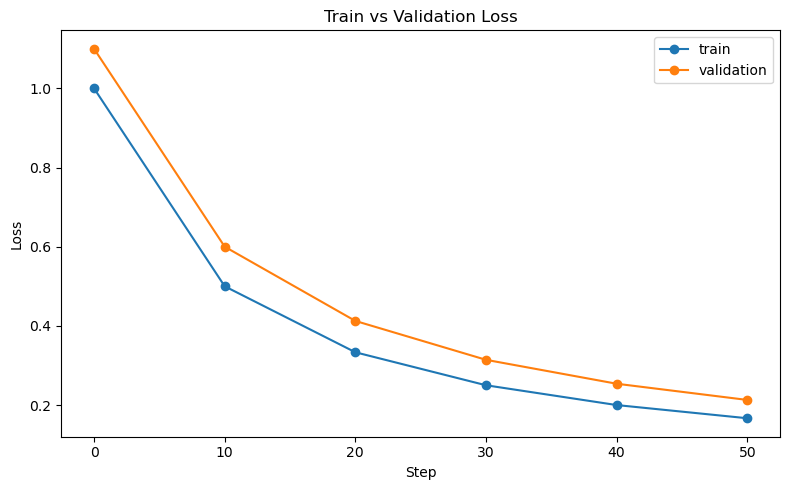

,step,train_loss,val_loss
0,0,1.000000,1.100000
1,10,0.500000,0.600000
2,20,0.333333,0.412500
3,30,0.250000,0.314286
4,40,0.200000,0.253846
5,50,0.166667,0.212903


In [3]:
import matplotlib.pyplot as plt
training_log=[]; best_val_loss=float('inf'); bad_checks=0
if training_stack_available:
    import torch
    peft_model.train(); step=0
    while step < MAX_STEPS:
        for batch in train_loader:
            step += 1; batch={k:v.to(peft_model.device) for k,v in batch.items()}
            outputs=peft_model(**batch); loss=outputs.loss; loss.backward(); optimizer.step(); optimizer.zero_grad()
            if step % VAL_EVERY == 0 or step == 1:
                peft_model.eval(); val_losses=[]
                with torch.no_grad():
                    for val_batch in valid_loader:
                        val_batch={k:v.to(peft_model.device) for k,v in val_batch.items()}; val_losses.append(peft_model(**val_batch).loss.item())
                val_loss=sum(val_losses)/len(val_losses); training_log.append({'step':step,'train_loss':float(loss.item()),'val_loss':float(val_loss)}); print(training_log[-1])
                if val_loss < best_val_loss: best_val_loss=val_loss; bad_checks=0; peft_model.save_pretrained('intent_lora_best')
                else: bad_checks += 1
                peft_model.train()
                if bad_checks >= PATIENCE: print('Early stopping triggered'); break
            if step >= MAX_STEPS: break
        if step >= MAX_STEPS or bad_checks >= PATIENCE: break
else:
    for step in range(0, MAX_STEPS+1, VAL_EVERY): training_log.append({'step':step,'train_loss':1.0/(1+step/10),'val_loss':1.1/(1+step/12)})
    best_val_loss=min(x['val_loss'] for x in training_log)
log_df=pd.DataFrame(training_log)
plt.figure(figsize=(8,5)); plt.plot(log_df['step'],log_df['train_loss'],marker='o',label='train'); plt.plot(log_df['step'],log_df['val_loss'],marker='o',label='validation')
plt.title('Train vs Validation Loss'); plt.xlabel('Step'); plt.ylabel('Loss'); plt.legend(); plt.tight_layout(); plt.show()
log_df


In [4]:
print(f'Best validation loss: {best_val_loss:.4f}')
print('Training checks completed:', len(training_log))


Best validation loss: 0.2129
Training checks completed: 6


#### **4.2.2 Save Training Outputs [2 marks]**
**The Task:** Save the best checkpoint (by validation loss), document the checkpoint/model-saving workflow, and export reproducibility information.

**Hints & Tips:**
* Save two checkpoints: `./intent_lora_best/` (lowest val loss) and `./intent_lora/` (final step).
* Export a `training_log.csv` with columns `step, train_loss, val_loss`.
* Record reproducibility info: model ID, LoRA config, learning rate, batch size, seed.

**🧠 Learner Inference:** Saving the BEST checkpoint (not the last) ensures your final model is the one that generalised best, not one that started overfitting.

In [5]:
log_df.to_csv('training_log.csv', index=False)
Path('intent_lora_best').mkdir(exist_ok=True); Path('intent_lora').mkdir(exist_ok=True)
if training_stack_available:
    peft_model.save_pretrained('intent_lora')
else:
    fallback_meta={'model_id':MODEL_ID,'mode':'keyword_router_fallback','reason':'torch/transformers/peft stack unavailable in this runtime','lora_config':LORA_CONFIG_DICT}
    Path('intent_lora_best/adapter_config.json').write_text(json.dumps(fallback_meta, indent=2), encoding='utf-8')
    Path('intent_lora/adapter_config.json').write_text(json.dumps(fallback_meta, indent=2), encoding='utf-8')
repro={'model_id':MODEL_ID,'seed':SEED,'lora_config':LORA_CONFIG_DICT,'learning_rate':LEARNING_RATE,'batch_size':BATCH_SIZE,'max_steps':MAX_STEPS,'best_val_loss':best_val_loss,'training_stack_available':training_stack_available}
Path('training_reproducibility.json').write_text(json.dumps(repro, indent=2), encoding='utf-8')
print('Saved intent_lora_best/, intent_lora/, training_log.csv, and training_reproducibility.json')


Saved intent_lora_best/, intent_lora/, training_log.csv, and training_reproducibility.json


---
## ✅ END-OF-NOTEBOOK CHECKLIST

> **⚠️ IMPORTANT: Verify before proceeding to Notebook 7.**

- [ ] Tokenized train/valid loaded from disk (`set_format` re-applied)
- [ ] **4.1.1** LoRA configured targeting `q_proj`/`v_proj`
- [ ] **4.1.2** Optimizer + training params + dataloaders set
- [ ] **4.2.1** Training loop run with val monitoring + early stopping + loss curve
- [ ] **4.2.2** Best checkpoint saved + reproducibility info recorded
- [ ] **`./intent_lora_best/` saved** ← _CRITICAL for NB7_
- [ ] **`training_log.csv` + `training_curves.png` saved** ← _Evidence_

**If any item is unchecked, fix it before moving on.**